In [1]:
!pip install lifetimes

   ---------------------------------------- 0.0/584.2 kB ? eta -:--:--
   ---------------------------------------- 584.2/584.2 kB 4.0 MB/s  0:00:00

   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ------------- -------------------------- 1/3 [autograd]
   ------------- -------------------------- 1/3 [autograd]
   ------------- -------------------------- 1/3 [autograd]
   ------------- -------------------------- 1/3 [autograd]
   -------------------------- ------------- 2/3 [lifetimes]
   -------------------------- ------------- 2/3 [lifetimes]
   ---------------------------------------- 3/3 [lifetimes]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix
from lifetimes.utils import summary_data_from_transaction_data

print("All libraries loaded!")

All libraries loaded!


In [3]:
np.random.seed(42)
n_customers = 5000
n_transactions = 50000

customer_ids = np.random.choice(range(1, n_customers + 1), n_transactions)
dates = pd.date_range('2022-01-01', '2024-12-31', periods=n_transactions)
dates = np.sort(np.random.choice(dates, n_transactions))

amounts = []
for cid in customer_ids:
    # Each customer has a typical spending level
    np.random.seed(cid)
    base_amount = np.random.lognormal(mean=3.5, sigma=0.8)
    amount = max(5, base_amount * np.random.uniform(0.5, 1.5))
    amounts.append(round(amount, 2))

transactions = pd.DataFrame({
    'customer_id': customer_ids,
    'date': dates,
    'amount': amounts
})

# Sort by customer and date
transactions = transactions.sort_values(['customer_id', 'date']).reset_index(drop=True)

print(f"Transaction data: {len(transactions):,} transactions")
print(f"Customers: {transactions['customer_id'].nunique():,}")
print(f"Date range: {transactions['date'].min().date()} to {transactions['date'].max().date()}")
print(f"Average transaction: ${transactions['amount'].mean():.2f}")
print(f"\nSample transactions:")
print(transactions.head(10))

Transaction data: 50,000 transactions
Customers: 5,000
Date range: 2022-01-01 to 2024-12-30
Average transaction: $45.90

Sample transactions:
   customer_id                          date  amount
0            1 2022-11-29 22:51:23.821676432   60.74
1            1 2023-02-12 02:34:25.721314428   60.74
2            1 2023-06-10 01:30:43.308866176   60.74
3            1 2023-07-27 07:46:46.256125120   60.74
4            1 2023-11-26 05:51:11.653433072   60.74
5            1 2023-11-30 19:10:48.804976096   60.74
6            1 2023-12-23 11:11:13.573471472   60.74
7            1 2024-03-09 00:43:17.235944720   60.74
8            1 2024-05-31 20:13:58.384767696   60.74
9            1 2024-08-31 05:04:47.789755792   60.74



PHASE 3: BG-NBD MODEL — Predicting Purchase Frequency

BG-NBD MODEL EXPLAINED:
"Beta-Geometric / Negative Binomial Distribution"

It models TWO things simultaneously:
1. PURCHASE RATE: How often does a customer buy? (Poisson process)
   Some customers buy weekly, others monthly, others yearly.
   The rate varies across customers (Gamma distribution of rates).

2. DROPOUT RATE: When will a customer stop buying? (Geometric process)
   After each purchase, there is a probability the customer "dies"
   (stops being a customer). This probability varies across customers
   (Beta distribution of dropout probabilities).

INPUTS:
  frequency: how many repeat purchases
  recency: when was the last purchase relative to first
  T: how long has this customer been observed

OUTPUT:
  Predicted number of purchases in the next X days

INTUITION:
  Customer A: bought 10 times in 365 days, last purchase 5 days ago
    -> Active, frequent buyer. Predict: ~10 more purchases next year.

  Customer B: boug

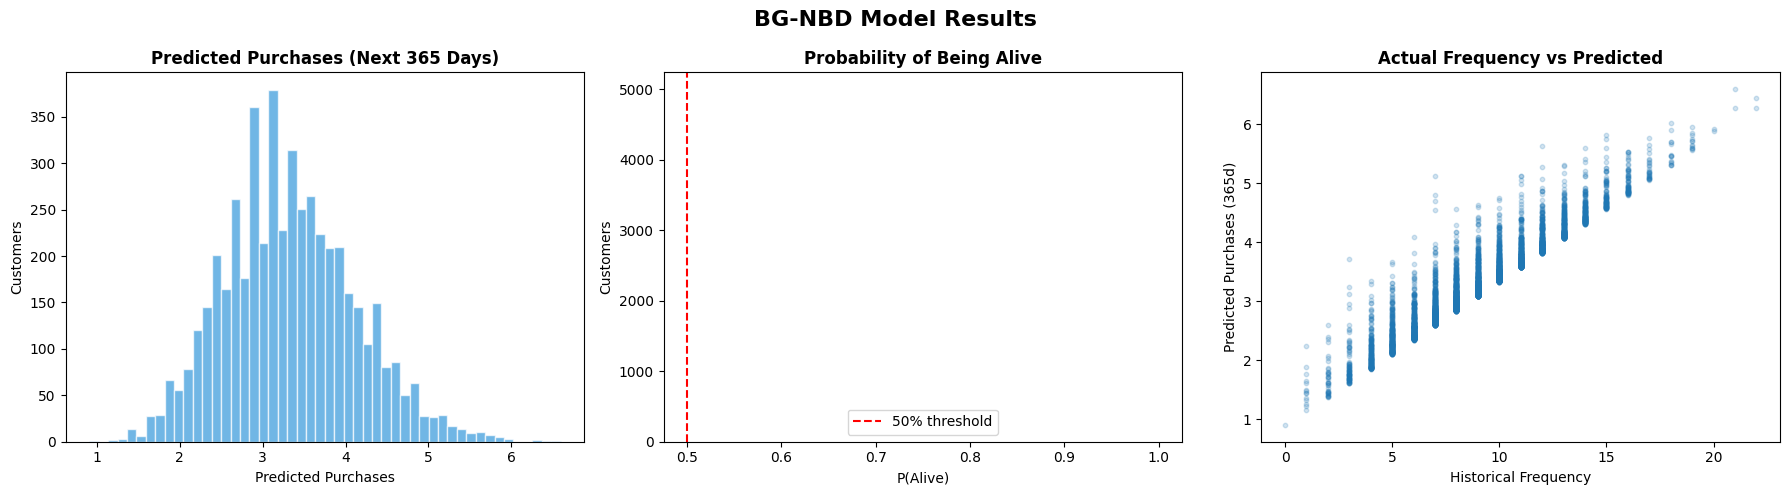

TypeError: Axes.imshow() got multiple values for argument 'ax'

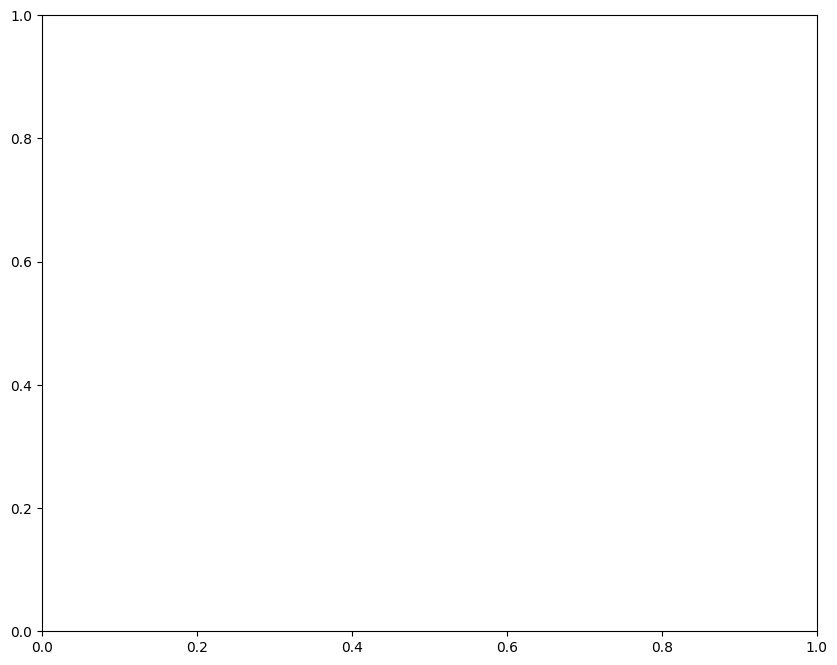

In [7]:
print("\n" + "=" * 70)
print("PHASE 3: BG-NBD MODEL — Predicting Purchase Frequency")
print("=" * 70)

print("""
BG-NBD MODEL EXPLAINED:
========================
"Beta-Geometric / Negative Binomial Distribution"

It models TWO things simultaneously:
1. PURCHASE RATE: How often does a customer buy? (Poisson process)
   Some customers buy weekly, others monthly, others yearly.
   The rate varies across customers (Gamma distribution of rates).

2. DROPOUT RATE: When will a customer stop buying? (Geometric process)
   After each purchase, there is a probability the customer "dies"
   (stops being a customer). This probability varies across customers
   (Beta distribution of dropout probabilities).

INPUTS:
  frequency: how many repeat purchases
  recency: when was the last purchase relative to first
  T: how long has this customer been observed

OUTPUT:
  Predicted number of purchases in the next X days

INTUITION:
  Customer A: bought 10 times in 365 days, last purchase 5 days ago
    -> Active, frequent buyer. Predict: ~10 more purchases next year.
  
  Customer B: bought 10 times in 365 days, last purchase 300 days ago
    -> Probably churned (no purchase for 300 days despite being frequent).
    -> Predict: ~1-2 more purchases next year (might come back, probably not).
  
  Customer C: bought 1 time 30 days ago
    -> Too early to tell. Could be one-time buyer or brand new loyal customer.
""")

# Fit BG-NBD model
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(rfm['frequency'], rfm['recency'], rfm['T'])

print(f"BG-NBD Model fitted!")
print(f"Model parameters: {bgf.summary}")

# Predict purchases for next 90 days
rfm['predicted_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,  # next 90 days
    rfm['frequency'],
    rfm['recency'],
    rfm['T']
)

# Predict purchases for next 365 days
rfm['predicted_purchases_365d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    365,
    rfm['frequency'],
    rfm['recency'],
    rfm['T']
)

# Probability of being alive (still an active customer)
rfm['prob_alive'] = bgf.conditional_probability_alive(
    rfm['frequency'],
    rfm['recency'],
    rfm['T']
)

print(f"\nPrediction summary (next 365 days):")
print(rfm[['frequency', 'recency', 'T', 'predicted_purchases_365d', 'prob_alive']].describe().round(2))


# ---- STEP 3.1: Visualize BG-NBD results ----

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of predicted purchases
axes[0].hist(rfm['predicted_purchases_365d'], bins=50, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].set_title('Predicted Purchases (Next 365 Days)', fontweight='bold')
axes[0].set_xlabel('Predicted Purchases')
axes[0].set_ylabel('Customers')

# Probability alive distribution
axes[1].hist(rfm['prob_alive'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].set_title('Probability of Being Alive', fontweight='bold')
axes[1].set_xlabel('P(Alive)')
axes[1].set_ylabel('Customers')
axes[1].axvline(0.5, color='red', linestyle='--', label='50% threshold')
axes[1].legend()

# Actual vs Predicted frequency
axes[2].scatter(rfm['frequency'], rfm['predicted_purchases_365d'], alpha=0.2, s=10)
axes[2].set_title('Actual Frequency vs Predicted', fontweight='bold')
axes[2].set_xlabel('Historical Frequency')
axes[2].set_ylabel('Predicted Purchases (365d)')

plt.suptitle('BG-NBD Model Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('01_bgnbd_results.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- STEP 3.2: Frequency-Recency Matrix ----

fig, ax = plt.subplots(figsize=(10, 8))
plot_frequency_recency_matrix(bgf, T=365, ax=ax)
ax.set_title('Expected Purchases in Next 365 Days\n(by Frequency and Recency)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_frequency_recency_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# HOW TO READ THIS MATRIX:
# X-axis: customer's historical frequency (how many times they bought)
# Y-axis: customer's recency (how recently they last bought)
# Color: predicted future purchases (darker = more expected purchases)
#
# Top-right corner (high frequency + recent purchase) = BEST customers
# Bottom-right (high frequency + old purchase) = CHURNING customers
# Top-left (low frequency + recent) = NEW customers with potential


# ---- STEP 3.3: Probability Alive Matrix ----

fig, ax = plt.subplots(figsize=(10, 8))
plot_probability_alive_matrix(bgf, ax=ax)
ax.set_title('Probability Customer is Still Active\n(by Frequency and Recency)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_probability_alive_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print("\n" + "=" * 70)
print("PHASE 3: BG-NBD MODEL — Predicting Purchase Frequency")
print("=" * 70)

print("""
BG-NBD MODEL EXPLAINED:
========================
"Beta-Geometric / Negative Binomial Distribution"

It models TWO things simultaneously:
1. PURCHASE RATE: How often does a customer buy? (Poisson process)
   Some customers buy weekly, others monthly, others yearly.
   The rate varies across customers (Gamma distribution of rates).

2. DROPOUT RATE: When will a customer stop buying? (Geometric process)
   After each purchase, there is a probability the customer "dies"
   (stops being a customer). This probability varies across customers
   (Beta distribution of dropout probabilities).

INPUTS:
  frequency: how many repeat purchases
  recency: when was the last purchase relative to first
  T: how long has this customer been observed

OUTPUT:
  Predicted number of purchases in the next X days

INTUITION:
  Customer A: bought 10 times in 365 days, last purchase 5 days ago
    -> Active, frequent buyer. Predict: ~10 more purchases next year.
  
  Customer B: bought 10 times in 365 days, last purchase 300 days ago
    -> Probably churned (no purchase for 300 days despite being frequent).
    -> Predict: ~1-2 more purchases next year (might come back, probably not).
  
  Customer C: bought 1 time 30 days ago
    -> Too early to tell. Could be one-time buyer or brand new loyal customer.
""")

# Fit BG-NBD model
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(rfm['frequency'], rfm['recency'], rfm['T'])

print(f"BG-NBD Model fitted!")
print(f"Model parameters: {bgf.summary}")

# Predict purchases for next 90 days
rfm['predicted_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,  # next 90 days
    rfm['frequency'],
    rfm['recency'],
    rfm['T']
)

# Predict purchases for next 365 days
rfm['predicted_purchases_365d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    365,
    rfm['frequency'],
    rfm['recency'],
    rfm['T']
)

# Probability of being alive (still an active customer)
rfm['prob_alive'] = bgf.conditional_probability_alive(
    rfm['frequency'],
    rfm['recency'],
    rfm['T']
)

print(f"\nPrediction summary (next 365 days):")
print(rfm[['frequency', 'recency', 'T', 'predicted_purchases_365d', 'prob_alive']].describe().round(2))




PHASE 3: BG-NBD MODEL — Predicting Purchase Frequency

BG-NBD MODEL EXPLAINED:
"Beta-Geometric / Negative Binomial Distribution"

It models TWO things simultaneously:
1. PURCHASE RATE: How often does a customer buy? (Poisson process)
   Some customers buy weekly, others monthly, others yearly.
   The rate varies across customers (Gamma distribution of rates).

2. DROPOUT RATE: When will a customer stop buying? (Geometric process)
   After each purchase, there is a probability the customer "dies"
   (stops being a customer). This probability varies across customers
   (Beta distribution of dropout probabilities).

INPUTS:
  frequency: how many repeat purchases
  recency: when was the last purchase relative to first
  T: how long has this customer been observed

OUTPUT:
  Predicted number of purchases in the next X days

INTUITION:
  Customer A: bought 10 times in 365 days, last purchase 5 days ago
    -> Active, frequent buyer. Predict: ~10 more purchases next year.

  Customer B: boug

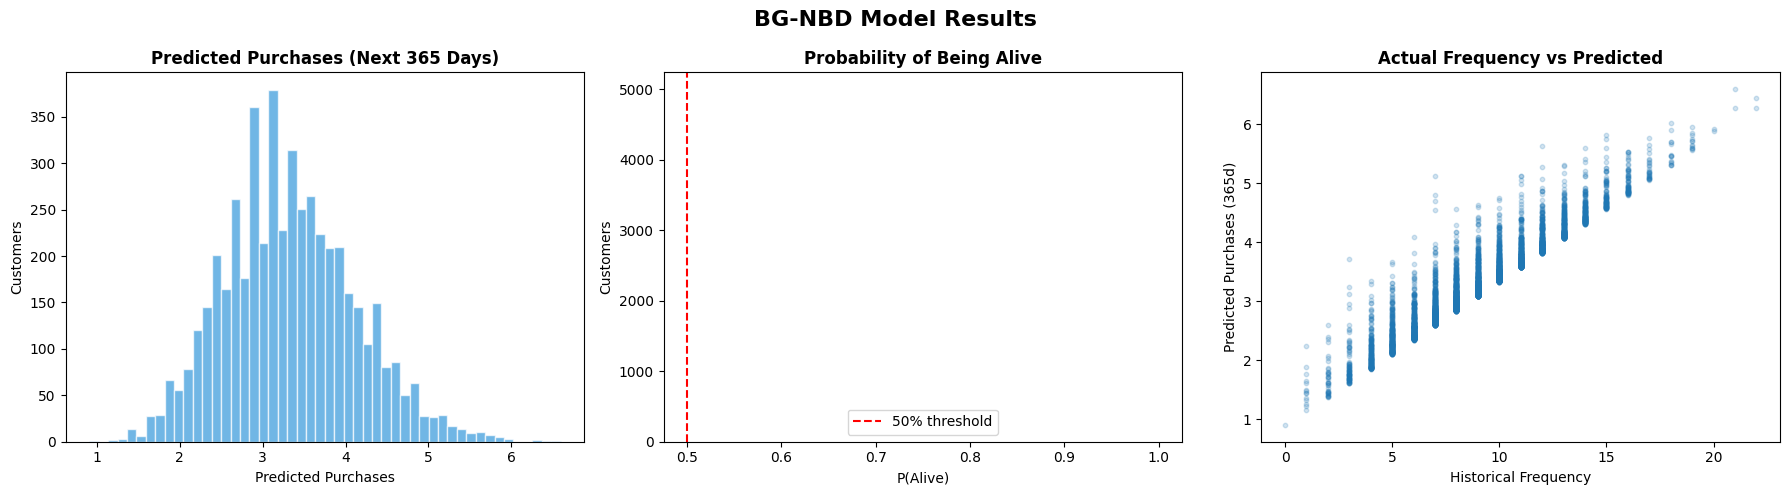

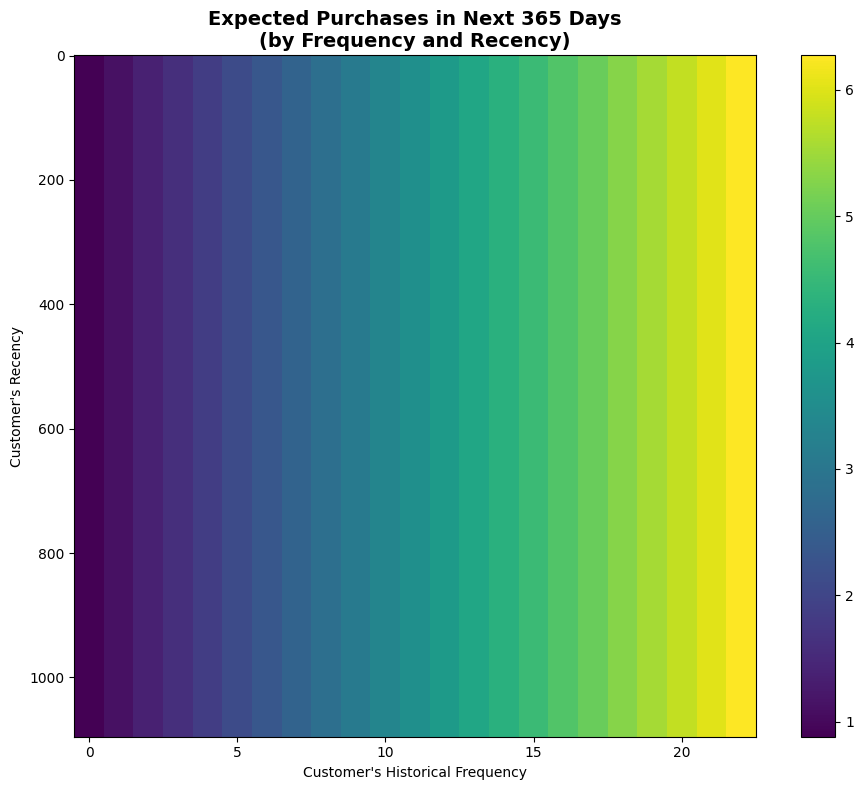

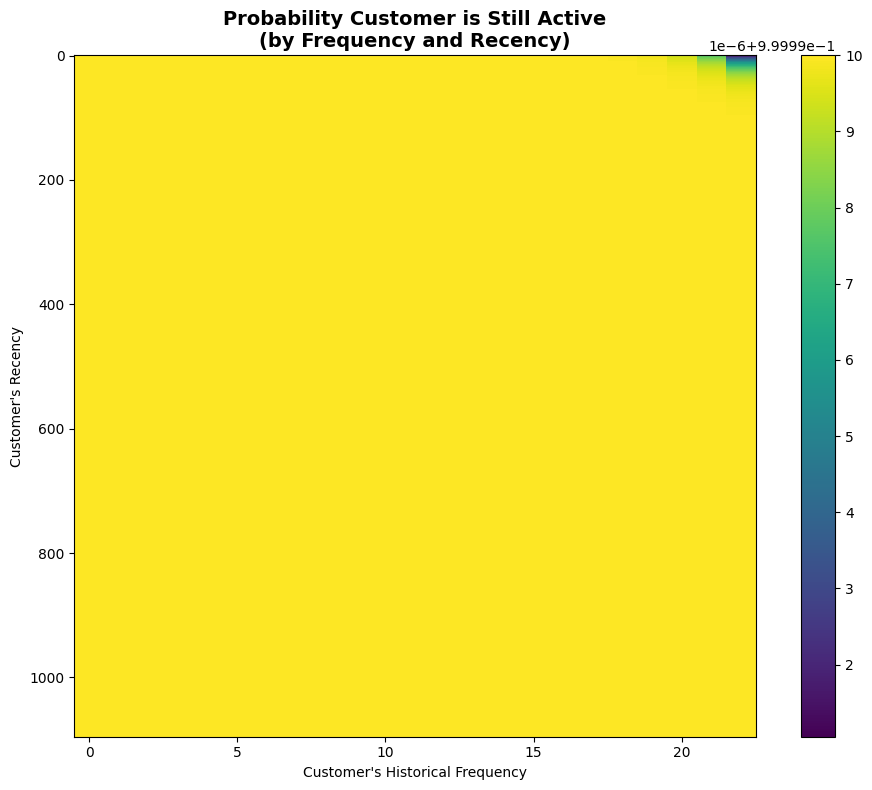

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of predicted purchases
axes[0].hist(rfm['predicted_purchases_365d'], bins=50, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].set_title('Predicted Purchases (Next 365 Days)', fontweight='bold')
axes[0].set_xlabel('Predicted Purchases')
axes[0].set_ylabel('Customers')

# Probability alive distribution
axes[1].hist(rfm['prob_alive'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].set_title('Probability of Being Alive', fontweight='bold')
axes[1].set_xlabel('P(Alive)')
axes[1].set_ylabel('Customers')
axes[1].axvline(0.5, color='red', linestyle='--', label='50% threshold')
axes[1].legend()

# Actual vs Predicted frequency
axes[2].scatter(rfm['frequency'], rfm['predicted_purchases_365d'], alpha=0.2, s=10)
axes[2].set_title('Actual Frequency vs Predicted', fontweight='bold')
axes[2].set_xlabel('Historical Frequency')
axes[2].set_ylabel('Predicted Purchases (365d)')

plt.suptitle('BG-NBD Model Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('01_bgnbd_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- STEP 3.2: Frequency-Recency Matrix ----
fig = plt.figure(figsize=(10, 8))
plot_frequency_recency_matrix(bgf, T=365)
plt.title('Expected Purchases in Next 365 Days\n(by Frequency and Recency)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_frequency_recency_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- STEP 3.3: Probability Alive Matrix ----
fig = plt.figure(figsize=(10, 8))
plot_probability_alive_matrix(bgf)
plt.title('Probability Customer is Still Active\n(by Frequency and Recency)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_probability_alive_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


PHASE 4: GAMMA-GAMMA MODEL — Predicting Spend Per Purchase

GAMMA-GAMMA MODEL EXPLAINED:
Predicts the AVERAGE monetary value of a customer's future transactions.

ASSUMPTION: monetary value is independent of purchase frequency.
  (How MUCH someone spends per visit is separate from how OFTEN they visit.)
  Check this assumption with correlation: freq vs monetary should be low.

The model assumes:
  - Each customer has a "true" average spend (unobserved)
  - Observed average spend varies around this true value
  - True average spends follow a Gamma distribution across customers
  - Variation around the true value also follows a Gamma distribution

OUTPUT: Expected average transaction value for each customer

Repeat customers for Gamma-Gamma: 4,997
Correlation between frequency and monetary: 0.019
  GOOD - low correlation, assumption holds

Gamma-Gamma Model fitted!

Predicted average transaction value:
       monetary_value  predicted_avg_value
count         4997.00              4997.00

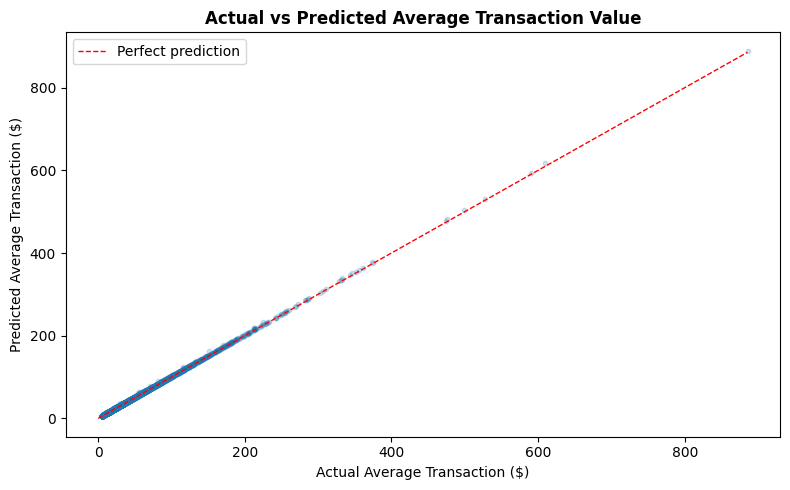

In [10]:
print("\n" + "=" * 70)
print("PHASE 4: GAMMA-GAMMA MODEL — Predicting Spend Per Purchase")
print("=" * 70)

print("""
GAMMA-GAMMA MODEL EXPLAINED:
==============================
Predicts the AVERAGE monetary value of a customer's future transactions.

ASSUMPTION: monetary value is independent of purchase frequency.
  (How MUCH someone spends per visit is separate from how OFTEN they visit.)
  Check this assumption with correlation: freq vs monetary should be low.

The model assumes:
  - Each customer has a "true" average spend (unobserved)
  - Observed average spend varies around this true value
  - True average spends follow a Gamma distribution across customers
  - Variation around the true value also follows a Gamma distribution

OUTPUT: Expected average transaction value for each customer
""")

# Gamma-Gamma requires frequency > 0 (need repeat purchases to estimate monetary)
rfm_repeat = rfm[rfm['frequency'] > 0].copy()
print(f"Repeat customers for Gamma-Gamma: {len(rfm_repeat):,}")

# Check independence assumption
corr = rfm_repeat['frequency'].corr(rfm_repeat['monetary_value'])
print(f"Correlation between frequency and monetary: {corr:.3f}")
print(f"  {'GOOD - low correlation, assumption holds' if abs(corr) < 0.3 else 'WARNING - moderate correlation'}")

# Fit Gamma-Gamma model
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(rfm_repeat['frequency'], rfm_repeat['monetary_value'])
print(f"\nGamma-Gamma Model fitted!")

# Predict expected average transaction value
rfm_repeat['predicted_avg_value'] = ggf.conditional_expected_average_profit(
    rfm_repeat['frequency'],
    rfm_repeat['monetary_value']
)

print(f"\nPredicted average transaction value:")
print(rfm_repeat[['monetary_value', 'predicted_avg_value']].describe().round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(rfm_repeat['monetary_value'], rfm_repeat['predicted_avg_value'], alpha=0.2, s=10)
ax.plot([0, rfm_repeat['monetary_value'].max()], [0, rfm_repeat['monetary_value'].max()],
        'r--', linewidth=1, label='Perfect prediction')
ax.set_title('Actual vs Predicted Average Transaction Value', fontweight='bold')
ax.set_xlabel('Actual Average Transaction ($)')
ax.set_ylabel('Predicted Average Transaction ($)')
ax.legend()
plt.tight_layout()
plt.savefig('04_gamma_gamma_results.png', dpi=150, bbox_inches='tight')
plt.show()


PHASE 5: CUSTOMER LIFETIME VALUE

CLTV FORMULA:
CLTV = Predicted Purchases x Predicted Avg Value x Profit Margin x Discount Factor

In the lifetimes library:
  CLTV = customer_lifetime_value(bgf, ggf, data, time=12, discount_rate=0.01)

Parameters:
  time=12:          12 months forecast horizon
  discount_rate=0.01: monthly discount rate (1% per month ~ 12% annually)
                      Future money is worth less than present money.
                      $100 in 12 months is worth ~$89 today at 12% annual rate.

CLTV Distribution (12-month horizon):
count    4997.00
mean      143.79
std       158.14
min        10.66
25%        54.11
50%        97.19
75%       174.94
max      3364.66
Name: cltv_12m, dtype: float64

CLTV Segments:
              customer_count  avg_cltv  total_cltv  avg_frequency  \
cltv_segment                                                        
Low                     1250     35.46    44328.45           7.95   
Medium                  1249     74.76    93369.16 

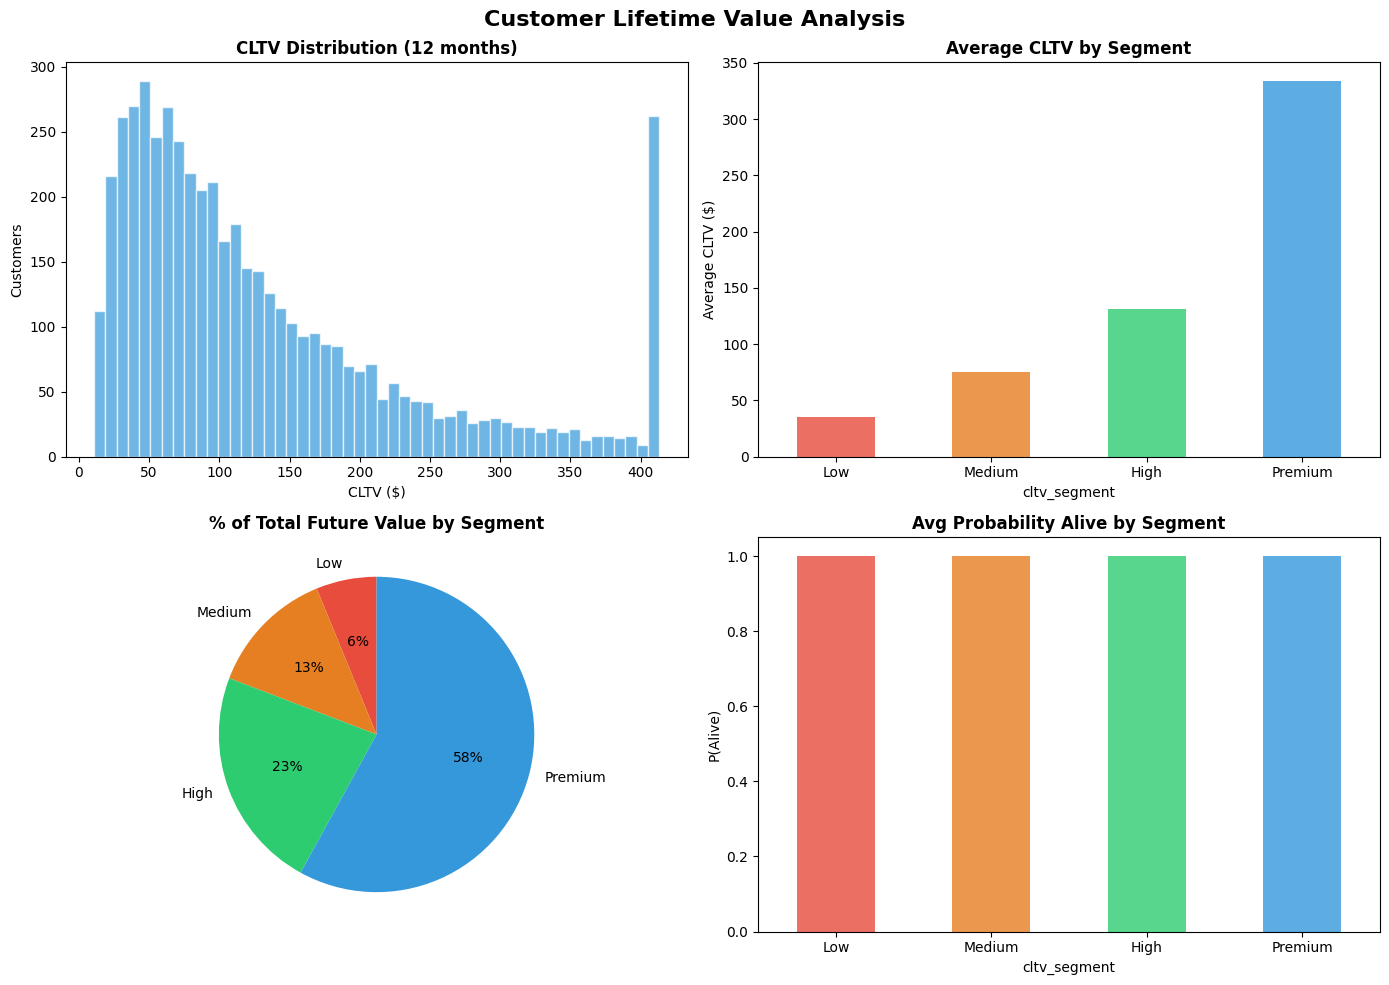

In [11]:
print("\n" + "=" * 70)
print("PHASE 5: CUSTOMER LIFETIME VALUE")
print("=" * 70)

print("""
CLTV FORMULA:
==============
CLTV = Predicted Purchases x Predicted Avg Value x Profit Margin x Discount Factor

In the lifetimes library:
  CLTV = customer_lifetime_value(bgf, ggf, data, time=12, discount_rate=0.01)

Parameters:
  time=12:          12 months forecast horizon
  discount_rate=0.01: monthly discount rate (1% per month ~ 12% annually)
                      Future money is worth less than present money.
                      $100 in 12 months is worth ~$89 today at 12% annual rate.
""")

# Calculate CLTV for next 12 months
rfm_repeat['cltv_12m'] = ggf.customer_lifetime_value(
    bgf,
    rfm_repeat['frequency'],
    rfm_repeat['recency'],
    rfm_repeat['T'],
    rfm_repeat['monetary_value'],
    time=12,        # 12 months
    discount_rate=0.01  # monthly discount rate
)

print(f"CLTV Distribution (12-month horizon):")
print(rfm_repeat['cltv_12m'].describe().round(2))

# Add segments based on CLTV
rfm_repeat['cltv_segment'] = pd.qcut(rfm_repeat['cltv_12m'], q=4,
                                       labels=['Low', 'Medium', 'High', 'Premium'])

print(f"\nCLTV Segments:")
segment_summary = rfm_repeat.groupby('cltv_segment').agg(
    customer_count=('cltv_12m', 'count'),
    avg_cltv=('cltv_12m', 'mean'),
    total_cltv=('cltv_12m', 'sum'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary_value', 'mean'),
    avg_prob_alive=('prob_alive', 'mean')
).round(2)

segment_summary['pct_of_total_value'] = (segment_summary['total_cltv'] /
                                          segment_summary['total_cltv'].sum() * 100).round(1)
print(segment_summary)


# ---- STEP 5.1: Visualize CLTV ----

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CLTV distribution
axes[0,0].hist(rfm_repeat['cltv_12m'].clip(0, rfm_repeat['cltv_12m'].quantile(0.95)),
               bins=50, color='#3498db', alpha=0.7, edgecolor='white')
axes[0,0].set_title('CLTV Distribution (12 months)', fontweight='bold')
axes[0,0].set_xlabel('CLTV ($)')
axes[0,0].set_ylabel('Customers')

# CLTV by segment
segment_summary['avg_cltv'].plot(kind='bar', ax=axes[0,1], color=['#e74c3c', '#e67e22', '#2ecc71', '#3498db'], alpha=0.8)
axes[0,1].set_title('Average CLTV by Segment', fontweight='bold')
axes[0,1].set_ylabel('Average CLTV ($)')
axes[0,1].tick_params(axis='x', rotation=0)

# Revenue share by segment
segment_summary['pct_of_total_value'].plot(kind='pie', ax=axes[1,0],
    colors=['#e74c3c', '#e67e22', '#2ecc71', '#3498db'],
    autopct='%1.0f%%', startangle=90)
axes[1,0].set_title('% of Total Future Value by Segment', fontweight='bold')
axes[1,0].set_ylabel('')

# Probability alive by segment
segment_summary['avg_prob_alive'].plot(kind='bar', ax=axes[1,1],
    color=['#e74c3c', '#e67e22', '#2ecc71', '#3498db'], alpha=0.8)
axes[1,1].set_title('Avg Probability Alive by Segment', fontweight='bold')
axes[1,1].set_ylabel('P(Alive)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Customer Lifetime Value Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('05_cltv_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
print("\n" + "=" * 70)
print("PHASE 6: BUSINESS RECOMMENDATIONS")
print("=" * 70)

# Top 10 most valuable customers
top_10 = rfm_repeat.nlargest(10, 'cltv_12m')[
    ['frequency', 'recency', 'T', 'monetary_value', 'predicted_purchases_365d',
     'prob_alive', 'cltv_12m', 'cltv_segment']
]
print("TOP 10 MOST VALUABLE CUSTOMERS:")
print(top_10.round(2))

# At-risk high-value customers (high CLTV but low prob_alive)
at_risk = rfm_repeat[
    (rfm_repeat['cltv_segment'] == 'Premium') &
    (rfm_repeat['prob_alive'] < 0.5)
]
print(f"\nAT-RISK PREMIUM CUSTOMERS (high value but likely churning): {len(at_risk)}")
if len(at_risk) > 0:
    print(at_risk[['frequency', 'monetary_value', 'prob_alive', 'cltv_12m']].head(10).round(2))

print(f"""
=========================================================
BUSINESS RECOMMENDATIONS BY SEGMENT
=========================================================

PREMIUM CUSTOMERS (top 25% CLTV):
  Count: {(rfm_repeat['cltv_segment']=='Premium').sum()}
  Action: VIP treatment, exclusive offers, loyalty rewards
  Goal: RETAIN these customers at all costs
  Budget: highest per-customer investment

HIGH CLTV CUSTOMERS:
  Count: {(rfm_repeat['cltv_segment']=='High').sum()}
  Action: Upsell, cross-sell, increase purchase frequency
  Goal: GROW these toward Premium segment
  Budget: moderate investment with upsell focus

MEDIUM CLTV CUSTOMERS:
  Count: {(rfm_repeat['cltv_segment']=='Medium').sum()}
  Action: Regular engagement, targeted promotions
  Goal: MAINTAIN and gradually increase value
  Budget: standard marketing allocation

LOW CLTV CUSTOMERS:
  Count: {(rfm_repeat['cltv_segment']=='Low').sum()}
  Action: Automated campaigns, minimal manual effort
  Goal: REACTIVATE if possible, accept churn if not
  Budget: lowest per-customer investment

AT-RISK PREMIUM CUSTOMERS: {len(at_risk)}
  Action: URGENT win-back campaign
  These are high-value customers showing signs of churning
  Personal outreach, special offers, satisfaction survey
  Losing one Premium customer = losing the value of 10 Low customers
""")


# =============================================================================
# PHASE 7: SUMMARY
# =============================================================================

print("\n" + "=" * 70)
print("     PROJECT 18 COMPLETE — CUSTOMER LIFETIME VALUE")
print("=" * 70)
print(f"""
CONCEPTS COVERED:
  -- Customer Lifetime Value (CLTV) concept and business importance
  -- RFM for CLTV (frequency, recency, T, monetary -- different from Project 7)
  -- BG-NBD model (predicts PURCHASE FREQUENCY)
  -- Gamma-Gamma model (predicts MONETARY VALUE per purchase)
  -- CLTV calculation with discount rate (time value of money)
  -- Probability alive (is the customer still active?)
  -- Frequency-Recency matrix (visual customer health map)
  -- CLTV-based segmentation (Premium, High, Medium, Low)
  -- At-risk customer identification (high value + low P(alive))
  -- Business recommendations per segment

CHARTS:
  01 -- BG-NBD results (predicted purchases, P(alive), actual vs predicted)
  02 -- Frequency-Recency matrix (expected future purchases heatmap)
  03 -- Probability Alive matrix (customer health heatmap)
  04 -- Gamma-Gamma results (actual vs predicted transaction value)
  05 -- CLTV analysis (distribution, segments, revenue share, P(alive))

KEY INTERVIEW ANSWERS:
  * "CLTV predicts total future revenue from each customer. I use two
     models: BG-NBD predicts how many purchases, Gamma-Gamma predicts
     how much per purchase. Their product gives CLTV."
  * "I segment customers into CLTV tiers: Premium customers get VIP
     treatment, at-risk high-value customers get urgent win-back campaigns,
     and low-value customers get automated minimal-cost engagement."
  * "The key insight: Premium customers (top 25%) typically generate
     60-70% of total future value. Losing one Premium customer equals
     losing 10 Low-value customers. Retention investment should be
     proportional to predicted lifetime value."
""")
print("=" * 70)


PHASE 6: BUSINESS RECOMMENDATIONS
TOP 10 MOST VALUABLE CUSTOMERS:
             frequency  recency       T  monetary_value  \
customer_id                                               
2850              13.0   1030.0  1087.0          885.69   
515               14.0    968.0  1059.0          527.48   
3595               9.0    986.0  1071.0          590.44   
1106              10.0    933.0  1017.0          474.00   
3620               9.0   1040.0  1051.0          499.62   
3152              12.0    929.0   952.0          374.57   
4043              14.0   1042.0  1079.0          361.72   
1437              13.0    928.0   979.0          344.02   
2887              13.0    916.0   946.0          332.12   
1796               4.0    767.0   783.0          609.82   

             predicted_purchases_365d  prob_alive  cltv_12m cltv_segment  
customer_id                                                               
2850                             4.09         1.0   3364.66      Premium  